# Active Preference Learning via Polytope Volume Removal

Instead of heuristic sample filtering, we maintain the feasible set $\Omega_t$ as an **explicit polytope** $\{\omega : A\omega \leq b\}$.

Each pairwise response (left, right, indifferent, incomparable) adds **linear constraints** on $\omega$,
and we select queries to **maximize expected volume removal** (Sadigh et al. 2017).

### Constraint rules (from the frame model)

Given query gaps $\Delta_j$ and thresholds $\tau, \tau'$:

| Response | Constraints on $\omega$ |
|----------|------------------------|
| **Left** ($Y \succ Y'$) | $\sum \omega_j |\Delta_j| \geq \tau$ and $\sum \omega_j (\Delta_j - \tau' |\Delta_j|) \geq 0$ |
| **Right** ($Y \prec Y'$) | $\sum \omega_j |\Delta_j| \geq \tau$ and $\sum \omega_j (\Delta_j + \tau' |\Delta_j|) \leq 0$ |
| **Indifferent** ($Y \sim Y'$) | $\sum \omega_j |\Delta_j| \leq \tau - \eta$ |
| **Incomparable** ($Y \bowtie Y'$) | $\sum \omega_j |\Delta_j| \geq \tau$, $\sum \omega_j (\Delta_j - \tau' |\Delta_j|) < 0$, $\sum \omega_j (\Delta_j + \tau' |\Delta_j|) > 0$ |

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import linprog
from scipy.spatial.distance import pdist
from typing import List, Tuple, Optional, Set
import matplotlib.pyplot as plt
import seaborn as sns

from core import (
    Patient, PairwiseQuery, FEATURE_NAMES, FEATURE_RANGES,
    compute_frame_gaps, predict_response, compute_aggregate_scores,
    generate_random_patient,
)
# Algorithm parameters
TAU = 0.5  # Intensity threshold
TAU_PRIME = 0.5  # Resolvability threshold
LAMBDA_X = 1.0  # Query scaling factor (can be a function later)
sns.set_style('whitegrid')

print(f'Features: {FEATURE_NAMES}')
print(f'tau={TAU}, tau_prime={TAU_PRIME}, lambda_x={LAMBDA_X}')

Features: ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']
tau=0.5, tau_prime=0.5, lambda_x=1.0


## Polytope class

H-representation: $\Omega = \{\omega \in \mathbb{R}^d : A\omega \leq b\}$

With hit-and-run MCMC sampling and Chebyshev center computation.

In [2]:
class ConstraintPolytope:
    """Convex polytope in H-representation: {w : Aw <= b}.

    For the simplex, we store the equality sum(w)=1 separately and
    handle it via two inequality constraints (sum <= 1, -sum <= -1).
    The Chebyshev center LP uses a tolerance approach to find a
    strictly interior point of the inequality system.
    """

    def __init__(self, dim: int, geometry: str = 'simplex'):
        self.dim = dim
        self.geometry = geometry
        self._A_rows = []
        self._b_vals = []
        self._center_cache = None
        self._use_sphere_constraint = False

        if geometry == 'simplex':
            # w_j >= 0  =>  -w_j <= 0
            for j in range(dim):
                row = np.zeros(dim)
                row[j] = -1.0
                self._A_rows.append(row)
                self._b_vals.append(0.0)
            # sum w_j <= 1
            self._A_rows.append(np.ones(dim))
            self._b_vals.append(1.0)
            # sum w_j >= 1  =>  -sum w_j <= -1
            self._A_rows.append(-np.ones(dim))
            self._b_vals.append(-1.0)

        elif geometry == 'sphere':
            for j in range(dim):
                row_pos = np.zeros(dim)
                row_pos[j] = 1.0
                self._A_rows.append(row_pos)
                self._b_vals.append(1.0)
                row_neg = np.zeros(dim)
                row_neg[j] = -1.0
                self._A_rows.append(row_neg)
                self._b_vals.append(1.0)
            self._use_sphere_constraint = True
        else:
            raise ValueError(f'Unknown geometry: {geometry}')

    @property
    def A(self) -> np.ndarray:
        return np.array(self._A_rows)

    @property
    def b(self) -> np.ndarray:
        return np.array(self._b_vals)

    @property
    def n_constraints(self) -> int:
        return len(self._A_rows)

    def add_constraint(self, a: np.ndarray, b_val: float):
        """Add constraint a^T w <= b_val."""
        self._A_rows.append(a.copy())
        self._b_vals.append(b_val)
        self._center_cache = None

    def is_feasible(self, w: np.ndarray, tol: float = 1e-8) -> bool:
        """Check if w satisfies all constraints."""
        violations = self.A @ w - self.b
        if np.any(violations > tol):
            return False
        if self._use_sphere_constraint and np.linalg.norm(w) > 1.0 + tol:
            return False
        return True

    def chebyshev_center(self) -> Optional[np.ndarray]:
        """Find a strictly interior point of the polytope.

        For polytopes with equality constraints (like the simplex where
        sum=1), the classical Chebyshev center has radius 0. Instead we
        find the point that maximizes the minimum slack across all
        INEQUALITY constraints (excluding exact equalities).

        We detect near-equalities (pairs a^T x <= b and -a^T x <= -b)
        and handle them as equality constraints in the LP.
        """
        if self._center_cache is not None:
            return self._center_cache.copy()

        A = self.A
        b_vec = self.b
        m, d = A.shape

        # Detect equality pairs: rows i,j where A[i] ≈ -A[j] and b[i] ≈ -b[j]
        eq_rows = set()
        ineq_rows = list(range(m))
        for i in range(m):
            for j in range(i + 1, m):
                if (np.allclose(A[i], -A[j], atol=1e-10) and
                        abs(b_vec[i] + b_vec[j]) < 1e-10):
                    eq_rows.add(i)
                    eq_rows.add(j)

        ineq_rows = [i for i in range(m) if i not in eq_rows]
        eq_row_list = sorted(eq_rows)

        if len(ineq_rows) == 0:
            # Only equalities — just solve for feasibility
            # Use one row from each equality pair
            seen = set()
            A_eq_rows = []
            b_eq_vals = []
            for i in eq_row_list:
                key = tuple(np.round(A[i], 10))
                neg_key = tuple(np.round(-A[i], 10))
                if key not in seen and neg_key not in seen:
                    seen.add(key)
                    A_eq_rows.append(A[i])
                    b_eq_vals.append(b_vec[i])
            A_eq = np.array(A_eq_rows)
            b_eq = np.array(b_eq_vals)
            # Least-norm solution
            x, _, _, _ = np.linalg.lstsq(A_eq, b_eq, rcond=None)
            if self.is_feasible(x):
                self._center_cache = x
                return x.copy()
            return None

        # Build LP: max r s.t. a_i^T x + r ||a_i|| <= b_i (for ineq rows)
        #           a_j^T x = b_j (for equality rows)
        A_ineq = A[ineq_rows]
        b_ineq = b_vec[ineq_rows]

        norms = np.linalg.norm(A_ineq, axis=1, keepdims=True)
        # Avoid division issues for zero-norm rows
        norms = np.maximum(norms, 1e-15)

        # Variables: [x_1, ..., x_d, r]
        c_obj = np.zeros(d + 1)
        c_obj[-1] = -1.0  # maximize r

        A_lp = np.hstack([A_ineq, norms])
        b_lp = b_ineq

        # Equality constraints from detected pairs (keep one per pair)
        A_eq_lp = None
        b_eq_lp = None
        if len(eq_row_list) > 0:
            seen = set()
            A_eq_rows = []
            b_eq_vals = []
            for i in eq_row_list:
                key = tuple(np.round(A[i], 10))
                neg_key = tuple(np.round(-A[i], 10))
                if key not in seen and neg_key not in seen:
                    seen.add(key)
                    A_eq_rows.append(np.append(A[i], 0.0))  # r doesn't appear
                    b_eq_vals.append(b_vec[i])
            if A_eq_rows:
                A_eq_lp = np.array(A_eq_rows)
                b_eq_lp = np.array(b_eq_vals)

        bounds = [(None, None)] * d + [(0, None)]

        result = linprog(c_obj, A_ub=A_lp, b_ub=b_lp,
                         A_eq=A_eq_lp, b_eq=b_eq_lp,
                         bounds=bounds, method='highs')

        if result.success:
            center = result.x[:d]
            if self.is_feasible(center):
                self._center_cache = center
                return center.copy()

        # Fallback: try the centroid (1/d, ..., 1/d) for simplex
        if self.geometry == 'simplex':
            centroid = np.ones(d) / d
            if self.is_feasible(centroid):
                self._center_cache = centroid
                return centroid.copy()

        return None

    def _hit_and_run_step(self, x: np.ndarray) -> np.ndarray:
        """One hit-and-run step: random direction, find chord, sample uniformly."""
        A = self.A
        b_vec = self.b

        direction = np.random.randn(self.dim)
        direction /= np.linalg.norm(direction)

        # For simplex: project direction onto the sum=1 hyperplane
        if self.geometry == 'simplex':
            direction -= direction.mean()
            norm = np.linalg.norm(direction)
            if norm < 1e-15:
                return x
            direction /= norm

        # Find t range: A(x + t*d) <= b  =>  t*(Ad) <= b - Ax
        Ad = A @ direction
        residuals = b_vec - A @ x

        t_min = -np.inf
        t_max = np.inf

        for i in range(len(Ad)):
            if Ad[i] > 1e-12:
                t_max = min(t_max, residuals[i] / Ad[i])
            elif Ad[i] < -1e-12:
                t_min = max(t_min, residuals[i] / Ad[i])

        if t_min >= t_max - 1e-15:
            return x

        # For sphere constraint, also clip t range
        if self._use_sphere_constraint:
            a_coef = np.dot(direction, direction)
            b_coef = 2 * np.dot(x, direction)
            c_coef = np.dot(x, x) - 1.0
            disc = b_coef**2 - 4 * a_coef * c_coef
            if disc > 0:
                sqrt_disc = np.sqrt(disc)
                t_lo = (-b_coef - sqrt_disc) / (2 * a_coef)
                t_hi = (-b_coef + sqrt_disc) / (2 * a_coef)
                t_min = max(t_min, t_lo)
                t_max = min(t_max, t_hi)
            else:
                return x

        if t_min >= t_max - 1e-15:
            return x

        t = np.random.uniform(t_min, t_max)
        return x + t * direction

    def sample(self, n_samples: int, burn_in: int = 500, thin: int = 10) -> np.ndarray:
        """Sample from the polytope using hit-and-run MCMC."""
        center = self.chebyshev_center()
        if center is None:
            raise ValueError('Polytope appears empty (no Chebyshev center found)')

        x = center.copy()
        samples = []

        total_steps = burn_in + n_samples * thin
        for step in range(total_steps):
            x = self._hit_and_run_step(x)
            if step >= burn_in and (step - burn_in) % thin == 0:
                samples.append(x.copy())

        return np.array(samples)


# Quick test
poly = ConstraintPolytope(5, geometry='simplex')
center = poly.chebyshev_center()
print(f'Simplex Chebyshev center: {center}')
print(f'Sum = {center.sum():.4f}, all >= 0: {np.all(center >= -1e-10)}')
print(f'Initial constraints: {poly.n_constraints}')

samples = poly.sample(500, burn_in=200, thin=5)
print(f'\nSampled {len(samples)} points from simplex')
print(f'  Sum range: [{samples.sum(axis=1).min():.6f}, {samples.sum(axis=1).max():.6f}]')
print(f'  Min weight: {samples.min():.4f}')
print(f'  Mean: {samples.mean(axis=0)}')

Simplex Chebyshev center: [0.2 0.2 0.2 0.2 0.2]
Sum = 1.0000, all >= 0: True
Initial constraints: 7

Sampled 500 points from simplex
  Sum range: [1.000000, 1.000000]
  Min weight: 0.0000
  Mean: [0.19598794 0.22959042 0.19019248 0.19979979 0.18442937]


In [3]:
# Also test sphere geometry
poly_sphere = ConstraintPolytope(5, geometry='sphere')
center_s = poly_sphere.chebyshev_center()
print(f'Sphere Chebyshev center: {center_s}')
print(f'||center|| = {np.linalg.norm(center_s):.4f}')

samples_s = poly_sphere.sample(500, burn_in=200, thin=5)
norms = np.linalg.norm(samples_s, axis=1)
print(f'\nSampled {len(samples_s)} points from unit ball')
print(f'  ||w|| range: [{norms.min():.4f}, {norms.max():.4f}]')
print(f'  Mean: {samples_s.mean(axis=0)}')

Sphere Chebyshev center: [-0. -0. -0. -0. -0.]
||center|| = 0.0000

Sampled 500 points from unit ball
  ||w|| range: [0.2978, 0.9998]
  Mean: [-0.01628168  0.01152936  0.01347708  0.00174054  0.01347593]


## Constraint generation from responses

Convert each (query, response) pair into linear constraints $a^\top \omega \leq b$.

In [4]:
def response_to_constraints(
    query: PairwiseQuery,
    response: str,
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
) -> List[Tuple[np.ndarray, float]]:
    """
    Convert a (query, response) into linear constraints on omega.

    Returns list of (a, b) where each represents: a^T omega <= b.

    Only active frames (|Δ_j| >= tau) participate.

    For strict inequalities (incomparable, indifferent), we use the
    non-strict form (<=, >=) since the boundary has measure zero and
    doesn't affect volume. This avoids the need for an eta parameter
    that could accidentally exclude the true weights.

    Left:          r >= tau  AND  Delta >= tau' * r
    Right:         r >= tau  AND  Delta <= -tau' * r
    Indifferent:   r <= tau  (non-strict relaxation of r < tau)
    Incomparable:  r >= tau  AND  Delta <= tau' * r  AND  Delta >= -tau' * r
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, tau)
    abs_gaps = np.abs(gaps)

    # Zero out inactive frames
    mask = np.zeros(len(gaps))
    for j in active_frames:
        mask[j] = 1.0
    gaps_active = gaps * mask
    abs_gaps_active = abs_gaps * mask

    constraints = []

    if response == 'left':
        # r >= tau  =>  -|Δ|^T ω <= -tau
        constraints.append((-abs_gaps_active, -tau))
        # Delta >= tau' * r  =>  -(Δ - τ'|Δ|)^T ω <= 0
        constraints.append((-(gaps_active - tau_prime * abs_gaps_active), 0.0))

    elif response == 'right':
        # r >= tau
        constraints.append((-abs_gaps_active, -tau))
        # Delta <= -tau' * r  =>  (Δ + τ'|Δ|)^T ω <= 0
        constraints.append((gaps_active + tau_prime * abs_gaps_active, 0.0))

    elif response == 'indifferent':
        # r <= tau  (non-strict: boundary has measure zero)
        constraints.append((abs_gaps_active, tau))

    elif response == 'incomparable':
        # r >= tau
        constraints.append((-abs_gaps_active, -tau))
        # Delta <= tau' * r  (non-strict)  =>  (Δ - τ'|Δ|)^T ω <= 0
        constraints.append((gaps_active - tau_prime * abs_gaps_active, 0.0))
        # Delta >= -tau' * r  (non-strict)  =>  -(Δ + τ'|Δ|)^T ω <= 0
        constraints.append((-(gaps_active + tau_prime * abs_gaps_active), 0.0))

    else:
        raise ValueError(f'Unknown response: {response}')

    return constraints


def classify_samples_active(
    samples: np.ndarray,
    query: PairwiseQuery,
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
) -> np.ndarray:
    """
    Classify each sample using active-frame logic (matching predict_response).
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, tau)

    if len(active_frames) == 0:
        return np.full(len(samples), 'indifferent', dtype=object)

    active_list = sorted(list(active_frames))
    active_gaps = gaps[active_list]
    abs_active_gaps = np.abs(active_gaps)
    active_weights = samples[:, active_list]

    r_vals = active_weights @ abs_active_gaps
    delta_vals = active_weights @ active_gaps

    N = len(samples)
    responses = np.empty(N, dtype=object)

    intense = r_vals >= tau
    responses[~intense] = 'indifferent'

    strongly_left = intense & (delta_vals >= tau_prime * r_vals)
    strongly_right = intense & (delta_vals <= -tau_prime * r_vals)
    incomparable = intense & ~strongly_left & ~strongly_right

    responses[strongly_left] = 'left'
    responses[strongly_right] = 'right'
    responses[incomparable] = 'incomparable'

    return responses


# Verify: oracle weights must satisfy constraints they generate
oracle_w_test = np.array([0.1, 0.5, 0.1, 0.1, 0.2])

test_left = Patient(0.6, 0.8, 0.2, 0.5, 0.4)
test_right = Patient(0.2, 0.2, 0.6, 0.3, 0.8)
test_query = PairwiseQuery(test_left, test_right)

resp = predict_response(test_query, oracle_w_test)
gaps_t, active_t = compute_frame_gaps(test_query, LAMBDA_X, TAU)
print(f'Test gaps: {gaps_t}')
print(f'Active frames (|gap| >= {TAU}): {sorted(active_t)}')
print(f'Oracle response: {resp}')

cs = response_to_constraints(test_query, resp)
print(f'\nConstraints ({len(cs)}):')
all_satisfied = True
for a, bv in cs:
    val = np.dot(a, oracle_w_test)
    ok = val <= bv + 1e-10
    all_satisfied &= ok
    print(f'  a^T w = {val:.6f} <= {bv:.6f}  {"OK" if ok else "VIOLATED!"}')
print(f'\nOracle satisfies all constraints: {all_satisfied}')

Test gaps: [ 0.4  0.6 -0.4  0.2 -0.4]
Active frames (|gap| >= 0.5): [1]
Oracle response: indifferent

Constraints (1):
  a^T w = 0.300000 <= 0.500000  OK

Oracle satisfies all constraints: True


## Volume removal query selection

Given samples from $\Omega_t$, select the query whose response will remove the most volume.

For each candidate query, classify every sample by which response it would produce,
then pick the query with the most balanced split (maximizes minimum volume removed).

In [5]:
def select_query_volume_removal(
    candidates: List[PairwiseQuery],
    samples: np.ndarray,
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
    decisive_only: bool = True,
) -> Tuple[PairwiseQuery, dict]:
    """
    Select query that maximizes the minimum volume removed across all
    possible responses (Sadigh et al. criterion).

    If decisive_only=True, only consider queries where a majority of
    samples predict 'left' or 'right' (i.e., the query will produce
    a decisive response). This filters out queries likely to yield
    indifferent or incomparable.
    """
    N = len(samples)
    best_query = None
    best_score = -1.0
    best_info = {}

    for query in candidates:
        responses = classify_samples_active(samples, query, tau, tau_prime, lambda_x)

        counts = {}
        for r in ['left', 'right', 'indifferent', 'incomparable']:
            counts[r] = np.sum(responses == r)

        # Filter: skip queries where the most likely response is not left/right
        if decisive_only:
            decisive_count = counts['left'] + counts['right']
            if decisive_count < N * 0.5:
                continue

        active_fracs = [c / N for c in counts.values() if c > 0]
        if len(active_fracs) == 0:
            continue

        max_surviving = max(active_fracs)
        min_volume_removed = 1.0 - max_surviving

        if min_volume_removed > best_score:
            best_score = min_volume_removed
            best_query = query
            best_info = {
                'min_volume_removed': min_volume_removed,
                'counts': counts.copy(),
                'max_surviving_frac': max_surviving,
            }

    if best_query is None:
        # Fallback: no decisive query found, pick the best from all candidates
        for query in candidates:
            responses = classify_samples_active(samples, query, tau, tau_prime, lambda_x)
            counts = {}
            for r in ['left', 'right', 'indifferent', 'incomparable']:
                counts[r] = np.sum(responses == r)
            active_fracs = [c / N for c in counts.values() if c > 0]
            if len(active_fracs) == 0:
                continue
            max_surviving = max(active_fracs)
            min_volume_removed = 1.0 - max_surviving
            if min_volume_removed > best_score:
                best_score = min_volume_removed
                best_query = query
                best_info = {
                    'min_volume_removed': min_volume_removed,
                    'counts': counts.copy(),
                    'max_surviving_frac': max_surviving,
                    'fallback': True,
                }

    if best_query is None:
        best_query = candidates[0]
        best_info = {'min_volume_removed': 0.0, 'fallback': True}

    return best_query, best_info


print('Volume removal query selection defined (decisive_only=True by default).')

Volume removal query selection defined (decisive_only=True by default).


## Active learning loop

In [ ]:
from scipy.stats import norm as normal_dist
from typing import Callable


def predict_thurstone(query, weights, sigma=1.0):
    """Thurstone-Mosteller (Case V): P(left) = Phi(w . delta_x / sigma), sample from Bernoulli."""
    delta_x = query.patient_left.to_array() - query.patient_right.to_array()
    z = np.dot(weights, delta_x) / sigma
    prob_left = normal_dist.cdf(z)
    # Sample from Bernoulli instead of thresholding
    if np.random.rand() < prob_left:
        return 'left'
    else:
        return 'right'


def predict_bt(query, weights):
    """Bradley-Terry: P(left) = sigmoid(w . delta_x), sample from Bernoulli."""
    delta_x = query.patient_left.to_array() - query.patient_right.to_array()
    logit = np.dot(weights, delta_x)
    prob_left = 1.0 / (1.0 + np.exp(-logit))
    # Sample from Bernoulli instead of thresholding
    if np.random.rand() < prob_left:
        return 'left'
    else:
        return 'right'


def predict_frame(query, weights, tau=TAU, tau_prime=TAU_PRIME, lambda_x=LAMBDA_X):
    """Frame model (wrapper matching the oracle_model signature)."""
    return predict_response(query, weights, tau=tau, lambda_x=lambda_x, tau_prime=tau_prime)


def generate_candidate_queries_normalized(
    n_candidates: int = 50,
) -> List[PairwiseQuery]:
    """Generate candidate queries with features normalized to [0,1]."""
    candidates = []
    for _ in range(n_candidates):
        left = Patient(
            elderlyDep=np.random.uniform(0, 1),
            lifeYearsGained=np.random.uniform(0, 1),
            obesity=np.random.uniform(0, 1),
            weeklyWorkhours=np.random.uniform(0, 1),
            yearsWaiting=np.random.uniform(0, 1),
        )
        right = Patient(
            elderlyDep=np.random.uniform(0, 1),
            lifeYearsGained=np.random.uniform(0, 1),
            obesity=np.random.uniform(0, 1),
            weeklyWorkhours=np.random.uniform(0, 1),
            yearsWaiting=np.random.uniform(0, 1),
        )
        candidates.append(PairwiseQuery(left, right))
    return candidates


def active_learning_polytope(
    max_iterations: int = 100,
    n_samples: int = 1000,
    n_candidates: int = 100,
    geometry: str = 'simplex',
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
    oracle_weights: Optional[np.ndarray] = None,
    oracle_model: Callable = None,
    decisive_only: bool = True,
    target_diameter: float = 0.1,
    verbose: bool = True,
) -> Tuple[ConstraintPolytope, List[dict]]:
    """
    Active learning via polytope volume removal.

    Parameters
    ----------
    oracle_model : callable(query, weights) -> str
        Any function that takes a PairwiseQuery and weight vector and
        returns one of 'left', 'right', 'indifferent', 'incomparable'.
        Defaults to the frame model (predict_response).
    decisive_only : bool
        If True, query selection only considers queries likely to produce
        a decisive left/right response. Passed to select_query_volume_removal.
    """
    dim = len(FEATURE_NAMES)
    polytope = ConstraintPolytope(dim, geometry=geometry)
    history = []

    if oracle_weights is None:
        oracle_weights = np.array([0.1, 0.5, 0.1, 0.1, 0.2])
    if oracle_model is None:
        oracle_model = lambda q, w: predict_response(q, w, tau=tau, lambda_x=lambda_x, tau_prime=tau_prime)

    model_name = getattr(oracle_model, '__name__', str(oracle_model))

    if verbose:
        print(f'Polytope Active Learning ({geometry}, oracle={model_name}, decisive_only={decisive_only})')
        print(f'=' * 60)
        print(f'Oracle weights: {dict(zip(FEATURE_NAMES, oracle_weights))}')
        print(f'Target diameter: {target_diameter}')
        print(f'Max iterations: {max_iterations}')
        print()

    for iteration in range(max_iterations):
        # Sample from current polytope
        try:
            samples = polytope.sample(n_samples, burn_in=300, thin=5)
        except ValueError as e:
            if verbose:
                print(f'  Polytope empty! {e}')
            break

        # Compute diameter
        if len(samples) > 1:
            if len(samples) > 200:
                idx = np.random.choice(len(samples), 200, replace=False)
                sub = samples[idx]
            else:
                sub = samples
            diam = pdist(sub, metric='cityblock').max()
        else:
            diam = 0.0

        mean_w = samples.mean(axis=0)

        if verbose:
            print(f'Iteration {iteration + 1}')
            print(f'  Constraints: {polytope.n_constraints}')
            print(f'  L1 diameter: {diam:.4f}')
            print(f'  Mean w: {np.array2string(mean_w, precision=3)}')

        if diam <= target_diameter:
            if verbose:
                print(f'\n  Converged! Diameter {diam:.4f} <= {target_diameter}')
            history.append({
                'iteration': iteration + 1,
                'diameter': diam,
                'n_constraints': polytope.n_constraints,
                'mean_weights': mean_w.copy(),
            })
            break

        # Generate candidates and select query
        candidates = generate_candidate_queries_normalized(n_candidates)
        query, query_info = select_query_volume_removal(
            candidates, samples, tau, tau_prime, lambda_x,
            decisive_only=decisive_only,
        )

        if verbose:
            print(f'  Volume removal: {query_info.get("min_volume_removed", 0):.3f}')
            print(f'  Split: {query_info.get("counts", {})}')
            if query_info.get('fallback'):
                print(f'  (fallback: no decisive query found)')

        # Oracle response via pluggable model
        response = oracle_model(query, oracle_weights)

        if verbose:
            print(f'  Oracle response: {response}')

        # Add constraints (active-frame masked, non-strict)
        new_constraints = response_to_constraints(
            query, response, tau, tau_prime, lambda_x
        )
        for a, bv in new_constraints:
            polytope.add_constraint(a, bv)

        # Verify polytope still feasible
        center = polytope.chebyshev_center()
        if center is None:
            if verbose:
                print(f'  WARNING: Polytope became empty!')
            break

        # Cosine similarity to ground truth
        cos_sim = np.dot(mean_w, oracle_weights) / (
            np.linalg.norm(mean_w) * np.linalg.norm(oracle_weights) + 1e-10
        )

        history.append({
            'iteration': iteration + 1,
            'query': query,
            'response': response,
            'diameter': diam,
            'n_constraints': polytope.n_constraints,
            'mean_weights': mean_w.copy(),
            'cosine_similarity': cos_sim,
            'volume_removed': query_info.get('min_volume_removed', 0),
        })

        if verbose:
            print(f'  Cosine similarity to oracle: {cos_sim:.4f}')
            print()

    # Final summary
    try:
        final_samples = polytope.sample(n_samples, burn_in=300, thin=5)
        learned = final_samples.mean(axis=0)
        if verbose:
            print(f'\nLearned weights:')
            for fn, lw, ow in zip(FEATURE_NAMES, learned, oracle_weights):
                print(f'  {fn:20s}: {lw:.4f}  (oracle: {ow:.4f})')
            l1_err = np.abs(learned - oracle_weights).sum()
            print(f'\nL1 error: {l1_err:.4f}')
    except ValueError:
        if verbose:
            print('\nCould not sample from final polytope.')

    return polytope, history


print('Active learning loop defined.')
print('Available oracle models: predict_frame, predict_bt, predict_thurstone')

## Comparison: Bradley-Terry vs Polytope Active Learning

All experiments use a **frame-model oracle** with ground truth weights. We compare:

1. **BT + Forced Choice**: Oracle gives indifferent/incomparable → flip coin for left/right. Fit BT on all responses.
2. **BT + Filter (all queries)**: Discard indifferent/incomparable responses. Fit BT only on decisive. Query selection searches ALL queries.
3. **BT + Filter (decisive queries)**: Same as (2), but query selection only considers decisive queries.
4. **Polytope (ours)**: Full frame model constraints on all 4 response types.

In [7]:
from scipy.optimize import minimize

def fit_bt_weights_mle(comparisons, n_features=5, reg=1e-4):
    """
    Fit Bradley-Terry weights via MLE with simplex constraint.
    
    comparisons: list of (delta_x, y) where y=1 for left, y=0 for right
    Returns weights on the simplex (sum=1, non-negative).
    """
    if len(comparisons) == 0:
        return np.ones(n_features) / n_features
    
    def neg_log_likelihood(w):
        ll = 0
        for delta_x, y in comparisons:
            logit = np.dot(w, delta_x)
            # Numerically stable log-sigmoid
            if logit > 20:
                log_prob_left = 0.0
                log_prob_right = -logit
            elif logit < -20:
                log_prob_left = logit
                log_prob_right = 0.0
            else:
                log_prob_left = -np.log1p(np.exp(-logit))
                log_prob_right = -np.log1p(np.exp(logit))
            
            if y == 1:
                ll += log_prob_left
            else:
                ll += log_prob_right
        
        # L2 regularization to avoid divergence
        ll -= reg * np.sum(w ** 2)
        return -ll
    
    # Initial guess: uniform
    w0 = np.ones(n_features) / n_features
    
    # Constraints: sum = 1, w >= 0
    constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
    bounds = [(1e-6, 1) for _ in range(n_features)]
    
    result = minimize(neg_log_likelihood, w0, method='SLSQP',
                     bounds=bounds, constraints=constraints,
                     options={'maxiter': 500})
    
    # Ensure on simplex
    w_out = np.maximum(result.x, 0)
    w_out = w_out / (w_out.sum() + 1e-10)
    return w_out


def make_frame_oracle(tau, tau_prime, lambda_x=LAMBDA_X):
    """Factory that returns a frame oracle with the given tau, tau'."""
    def predict_frame_closure(query, weights):
        return predict_response(query, weights, tau=tau, lambda_x=lambda_x, tau_prime=tau_prime)
    predict_frame_closure.__name__ = f'frame(tau={tau},tau_prime={tau_prime})'
    return predict_frame_closure


# Quick test of BT fitting
np.random.seed(42)
test_comparisons = []
true_w = np.array([0.1, 0.5, 0.1, 0.1, 0.2])
for _ in range(50):
    delta_x = np.random.randn(5)
    prob_left = 1 / (1 + np.exp(-np.dot(true_w, delta_x)))
    y = 1 if np.random.rand() < prob_left else 0
    test_comparisons.append((delta_x, y))

fitted_w = fit_bt_weights_mle(test_comparisons)
print(f'True weights:   {true_w}')
print(f'Fitted weights: {fitted_w}')
print(f'Cosine sim:     {np.dot(true_w, fitted_w) / (np.linalg.norm(true_w) * np.linalg.norm(fitted_w)):.4f}')

True weights:   [0.1 0.5 0.1 0.1 0.2]
Fitted weights: [0.178052   0.10757858 0.29897673 0.27161718 0.14377551]
Cosine sim:     0.5839


In [ ]:
def run_comparison_experiment(
    oracle_weights: np.ndarray,
    tau: float,
    tau_prime: float,
    max_iterations: int = 30,
    n_samples: int = 1000,
    n_candidates: int = 100,
    verbose: bool = False,
) -> dict:
    """
    Run all 4 methods on the same oracle and return results.
    
    Methods:
    1. bt_forced: BT on forced-choice responses (coin flip for indiff/incomp)
    2. bt_filter_all: BT on decisive only, query selection searches all
    3. bt_filter_decisive: BT on decisive only, query selection filters decisive
    4. polytope: Our full polytope method with all 4 response types
    
    Returns dict with history for each method.
    """
    dim = len(FEATURE_NAMES)
    frame_oracle = make_frame_oracle(tau, tau_prime)
    
    results = {}
    
    # =========================================================================
    # Method 1: BT + Forced Choice
    # =========================================================================
    polytope_1 = ConstraintPolytope(dim, 'simplex')
    comparisons_1 = []
    history_1 = []
    
    for iteration in range(max_iterations):
        try:
            samples = polytope_1.sample(n_samples, burn_in=300, thin=5)
        except ValueError:
            break
        
        # Query selection (search all queries, use frame-model classification for volume removal)
        candidates = generate_candidate_queries_normalized(n_candidates)
        query, _ = select_query_volume_removal(candidates, samples, tau, tau_prime, LAMBDA_X, decisive_only=False)
        
        # Oracle response (frame model)
        true_response = frame_oracle(query, oracle_weights)
        
        # Forced choice: coin flip for indiff/incomp
        if true_response in ('left', 'right'):
            response = true_response
        else:
            response = np.random.choice(['left', 'right'])
        
        # Add to BT comparisons
        delta_x = query.patient_left.to_array() - query.patient_right.to_array()
        y = 1 if response == 'left' else 0
        comparisons_1.append((delta_x, y))
        
        # Add constraint to polytope (using tau=0 for BT model, just left/right)
        # For left: delta^T w >= 0, for right: delta^T w <= 0
        if response == 'left':
            polytope_1.add_constraint(-delta_x, 0.0)  # -delta^T w <= 0 => delta^T w >= 0
        else:
            polytope_1.add_constraint(delta_x, 0.0)   # delta^T w <= 0
        
        # Fit BT weights
        bt_weights = fit_bt_weights_mle(comparisons_1)
        
        # Metrics
        cos_sim = np.dot(bt_weights, oracle_weights) / (
            np.linalg.norm(bt_weights) * np.linalg.norm(oracle_weights) + 1e-10)
        l1_err = np.abs(bt_weights - oracle_weights).sum()
        
        history_1.append({
            'iteration': iteration + 1,
            'weights': bt_weights.copy(),
            'cosine_similarity': cos_sim,
            'l1_error': l1_err,
            'n_comparisons': len(comparisons_1),
            'true_response': true_response,
            'forced': true_response not in ('left', 'right'),
        })
    
    results['bt_forced'] = history_1
    
    # =========================================================================
    # Method 2: BT + Filter (all queries searched)
    # =========================================================================
    polytope_2 = ConstraintPolytope(dim, 'simplex')
    comparisons_2 = []
    history_2 = []
    
    for iteration in range(max_iterations):
        try:
            samples = polytope_2.sample(n_samples, burn_in=300, thin=5)
        except ValueError:
            break
        
        # Query selection (search ALL queries)
        candidates = generate_candidate_queries_normalized(n_candidates)
        query, _ = select_query_volume_removal(candidates, samples, tau, tau_prime, LAMBDA_X, decisive_only=False)
        
        # Oracle response
        true_response = frame_oracle(query, oracle_weights)
        
        # Only keep decisive responses
        if true_response in ('left', 'right'):
            delta_x = query.patient_left.to_array() - query.patient_right.to_array()
            y = 1 if true_response == 'left' else 0
            comparisons_2.append((delta_x, y))
            
            # Add constraint
            if true_response == 'left':
                polytope_2.add_constraint(-delta_x, 0.0)
            else:
                polytope_2.add_constraint(delta_x, 0.0)
        
        # Fit BT weights (even if no new comparison added)
        bt_weights = fit_bt_weights_mle(comparisons_2)
        
        cos_sim = np.dot(bt_weights, oracle_weights) / (
            np.linalg.norm(bt_weights) * np.linalg.norm(oracle_weights) + 1e-10)
        l1_err = np.abs(bt_weights - oracle_weights).sum()
        
        history_2.append({
            'iteration': iteration + 1,
            'weights': bt_weights.copy(),
            'cosine_similarity': cos_sim,
            'l1_error': l1_err,
            'n_comparisons': len(comparisons_2),
            'true_response': true_response,
            'skipped': true_response not in ('left', 'right'),
        })
    
    results['bt_filter_all'] = history_2
    
    # =========================================================================
    # Method 3: BT + Filter (decisive queries only)
    # =========================================================================
    polytope_3 = ConstraintPolytope(dim, 'simplex')
    comparisons_3 = []
    history_3 = []
    
    for iteration in range(max_iterations):
        try:
            samples = polytope_3.sample(n_samples, burn_in=300, thin=5)
        except ValueError:
            break
        
        # Query selection (ONLY decisive queries)
        candidates = generate_candidate_queries_normalized(n_candidates)
        query, _ = select_query_volume_removal(candidates, samples, tau, tau_prime, LAMBDA_X, decisive_only=True)
        
        # Oracle response
        true_response = frame_oracle(query, oracle_weights)
        
        # Only keep decisive responses
        if true_response in ('left', 'right'):
            delta_x = query.patient_left.to_array() - query.patient_right.to_array()
            y = 1 if true_response == 'left' else 0
            comparisons_3.append((delta_x, y))
            
            if true_response == 'left':
                polytope_3.add_constraint(-delta_x, 0.0)
            else:
                polytope_3.add_constraint(delta_x, 0.0)
        
        bt_weights = fit_bt_weights_mle(comparisons_3)
        
        cos_sim = np.dot(bt_weights, oracle_weights) / (
            np.linalg.norm(bt_weights) * np.linalg.norm(oracle_weights) + 1e-10)
        l1_err = np.abs(bt_weights - oracle_weights).sum()
        
        history_3.append({
            'iteration': iteration + 1,
            'weights': bt_weights.copy(),
            'cosine_similarity': cos_sim,
            'l1_error': l1_err,
            'n_comparisons': len(comparisons_3),
            'true_response': true_response,
            'skipped': true_response not in ('left', 'right'),
        })
    
    results['bt_filter_decisive'] = history_3
    
    # =========================================================================
    # Method 4: Polytope (ours) - full frame model
    # =========================================================================
    polytope_4 = ConstraintPolytope(dim, 'simplex')
    history_4 = []
    
    for iteration in range(max_iterations):
        try:
            samples = polytope_4.sample(n_samples, burn_in=300, thin=5)
        except ValueError:
            break
        
        mean_w = samples.mean(axis=0)
        
        # Query selection (decisive only for efficiency)
        candidates = generate_candidate_queries_normalized(n_candidates)
        query, _ = select_query_volume_removal(candidates, samples, tau, tau_prime, LAMBDA_X, decisive_only=False)
        
        # Oracle response
        true_response = frame_oracle(query, oracle_weights)
        
        # Add ALL constraints (including indifferent/incomparable)
        new_constraints = response_to_constraints(query, true_response, tau, tau_prime, LAMBDA_X)
        for a, bv in new_constraints:
            polytope_4.add_constraint(a, bv)
        
        # Check feasibility
        center = polytope_4.chebyshev_center()
        if center is None:
            break
        
        cos_sim = np.dot(mean_w, oracle_weights) / (
            np.linalg.norm(mean_w) * np.linalg.norm(oracle_weights) + 1e-10)
        l1_err = np.abs(mean_w - oracle_weights).sum()
        
        history_4.append({
            'iteration': iteration + 1,
            'weights': mean_w.copy(),
            'cosine_similarity': cos_sim,
            'l1_error': l1_err,
            'n_constraints': polytope_4.n_constraints,
            'true_response': true_response,
        })
    
    results['polytope'] = history_4
    
    return results


print('Comparison experiment function defined.')

Comparison experiment function defined.


In [9]:
# Run the comparison experiment across multiple weight vectors and trials
import time

np.random.seed(42)

# Experiment parameters
EXP_TAU = 0.3
EXP_TAU_PRIME = 0.3
n_weights = 10
n_trials = 10
max_iter = 40

weight_vectors = np.random.dirichlet(np.ones(5), size=n_weights)

# Store all results
all_results = []

t0 = time.time()
total = n_weights * n_trials
done = 0

for w_idx, w_vec in enumerate(weight_vectors):
    for trial in range(n_trials):
        np.random.seed(w_idx * 1000 + trial)
        
        res = run_comparison_experiment(
            oracle_weights=w_vec,
            tau=EXP_TAU,
            tau_prime=EXP_TAU_PRIME,
            max_iterations=max_iter,
            n_samples=1000,
            n_candidates=100,
        )
        all_results.append({
            'w_idx': w_idx,
            'trial': trial,
            'oracle_weights': w_vec.copy(),
            'results': res,
        })
        
        done += 1
        elapsed = time.time() - t0
        rate = done / elapsed if elapsed > 0 else 0
        remaining = (total - done) / rate if rate > 0 else 0
        
        if done % 10 == 0 or done == total:
            print(f'  [{done}/{total}] ~{remaining:.0f}s remaining')

print(f'\nAll done in {time.time() - t0:.1f}s')
print(f'tau={EXP_TAU}, tau_prime={EXP_TAU_PRIME}')

/Users/michellesi/anaconda3/lib/python3.10/site-packages/scipy/optimize/_optimize.py:353: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


  [10/100] ~2583s remaining
  [20/100] ~2232s remaining
  [30/100] ~1957s remaining
  [40/100] ~1674s remaining
  [50/100] ~1383s remaining
  [60/100] ~1105s remaining
  [70/100] ~826s remaining
  [80/100] ~550s remaining
  [90/100] ~278s remaining
  [100/100] ~0s remaining

All done in 2770.5s
tau=0.3, tau_prime=0.3


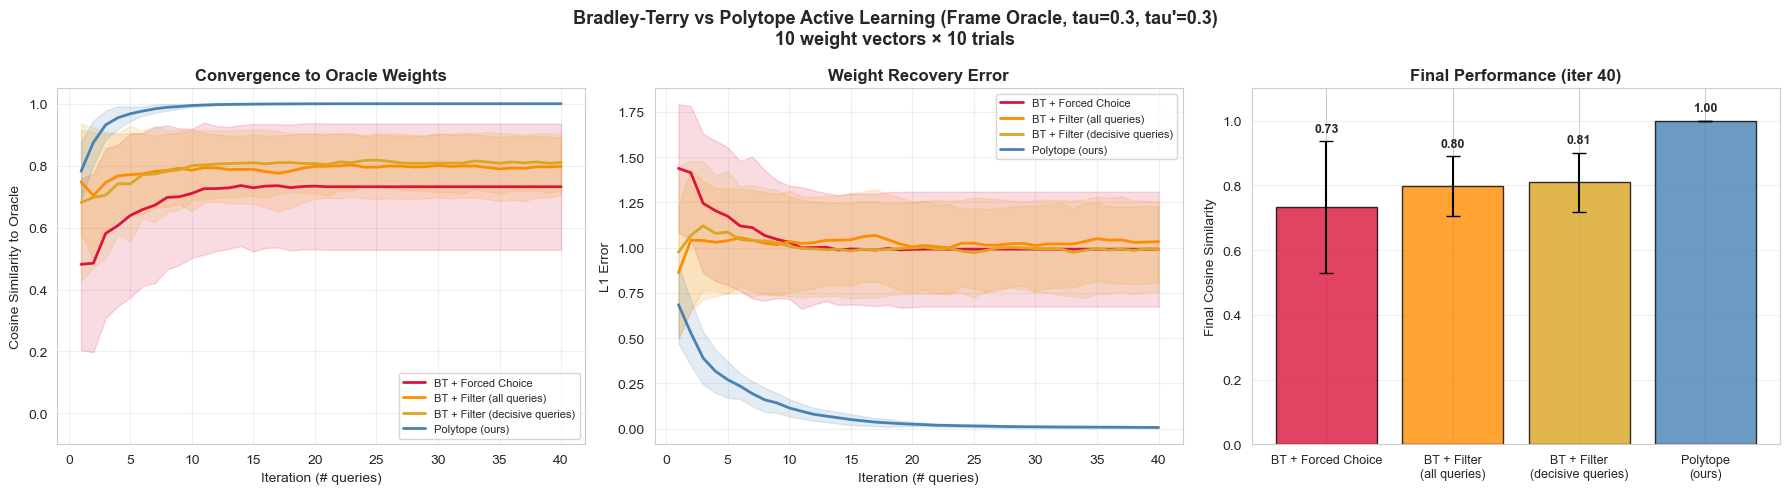


Summary Statistics (final iteration):
BT + Forced Choice                 : cos_sim = 0.732 ± 0.204, L1 = 0.991 ± 0.317
BT + Filter (all queries)          : cos_sim = 0.798 ± 0.093, L1 = 1.033 ± 0.221
BT + Filter (decisive queries)     : cos_sim = 0.810 ± 0.091, L1 = 0.991 ± 0.235
Polytope (ours)                    : cos_sim = 1.000 ± 0.000, L1 = 0.006 ± 0.004


In [10]:
# Aggregate and plot results
methods = ['bt_forced', 'bt_filter_all', 'bt_filter_decisive', 'polytope']
method_labels = {
    'bt_forced': 'BT + Forced Choice',
    'bt_filter_all': 'BT + Filter (all queries)',
    'bt_filter_decisive': 'BT + Filter (decisive queries)',
    'polytope': 'Polytope (ours)',
}
colors = {
    'bt_forced': 'crimson',
    'bt_filter_all': 'darkorange',
    'bt_filter_decisive': 'goldenrod',
    'polytope': 'steelblue',
}

# Extract cosine similarity and L1 error curves
def extract_metric(results, method, metric_key):
    """Extract metric curve, padded to max_iter."""
    curves = []
    for r in results:
        hist = r['results'].get(method, [])
        vals = [h.get(metric_key, np.nan) for h in hist]
        # Pad to max_iter
        while len(vals) < max_iter:
            vals.append(vals[-1] if vals else np.nan)
        curves.append(vals[:max_iter])
    return np.array(curves)

cos_sim_curves = {m: extract_metric(all_results, m, 'cosine_similarity') for m in methods}
l1_err_curves = {m: extract_metric(all_results, m, 'l1_error') for m in methods}

# Also count how many decisive responses each method got
def count_decisive(results, method):
    counts = []
    for r in results:
        hist = r['results'].get(method, [])
        n_decisive = sum(1 for h in hist if h.get('true_response') in ('left', 'right'))
        counts.append(n_decisive)
    return np.array(counts)

decisive_counts = {m: count_decisive(all_results, m) for m in methods}

# Plot
iters = np.arange(1, max_iter + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Cosine Similarity ---
ax = axes[0]
for m in methods:
    mean = np.nanmean(cos_sim_curves[m], axis=0)
    std = np.nanstd(cos_sim_curves[m], axis=0)
    ax.plot(iters, mean, '-', color=colors[m], label=method_labels[m], linewidth=2)
    ax.fill_between(iters, mean - std, mean + std, color=colors[m], alpha=0.15)
ax.set_xlabel('Iteration (# queries)')
ax.set_ylabel('Cosine Similarity to Oracle')
ax.set_title('Convergence to Oracle Weights', fontweight='bold')
ax.set_ylim(-0.1, 1.05)
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)

# --- L1 Error ---
ax = axes[1]
for m in methods:
    mean = np.nanmean(l1_err_curves[m], axis=0)
    std = np.nanstd(l1_err_curves[m], axis=0)
    ax.plot(iters, mean, '-', color=colors[m], label=method_labels[m], linewidth=2)
    ax.fill_between(iters, mean - std, mean + std, color=colors[m], alpha=0.15)
ax.set_xlabel('Iteration (# queries)')
ax.set_ylabel('L1 Error')
ax.set_title('Weight Recovery Error', fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

# --- Bar chart: final cosine similarity ---
ax = axes[2]
final_cos = {m: np.nanmean(cos_sim_curves[m][:, -1]) for m in methods}
final_cos_std = {m: np.nanstd(cos_sim_curves[m][:, -1]) for m in methods}

x_pos = np.arange(len(methods))
bars = ax.bar(x_pos, [final_cos[m] for m in methods],
              yerr=[final_cos_std[m] for m in methods], capsize=5,
              color=[colors[m] for m in methods], edgecolor='black', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels([method_labels[m].replace(' (', '\n(') for m in methods], fontsize=9)
ax.set_ylabel('Final Cosine Similarity')
ax.set_title(f'Final Performance (iter {max_iter})', fontweight='bold')
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

for bar, m in zip(bars, methods):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + final_cos_std[m] + 0.02,
            f'{final_cos[m]:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

fig.suptitle(f'Bradley-Terry vs Polytope Active Learning (Frame Oracle, tau={EXP_TAU}, tau\'={EXP_TAU_PRIME})\n'
             f'{n_weights} weight vectors × {n_trials} trials',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary statistics
print('\n' + '='*70)
print('Summary Statistics (final iteration):')
print('='*70)
for m in methods:
    cos_final = cos_sim_curves[m][:, -1]
    l1_final = l1_err_curves[m][:, -1]
    print(f'{method_labels[m]:35s}: cos_sim = {np.nanmean(cos_final):.3f} ± {np.nanstd(cos_final):.3f}, '
          f'L1 = {np.nanmean(l1_final):.3f} ± {np.nanstd(l1_final):.3f}')

In [ ]:
# Additional analysis: response breakdown and efficiency

# Count response types for each method
def count_response_types(results, method):
    """Count how many of each response type across all trials."""
    counts = {'left': 0, 'right': 0, 'indifferent': 0, 'incomparable': 0}
    total = 0
    for r in results:
        hist = r['results'].get(method, [])
        for h in hist:
            resp = h.get('true_response')
            if resp in counts:
                counts[resp] += 1
                total += 1
    return counts, total

response_counts = {m: count_response_types(all_results, m) for m in methods}

# Plot response breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Response type distribution ---
ax = axes[0]
resp_types = ['left', 'right', 'indifferent', 'incomparable']
resp_colors = {'left': 'forestgreen', 'right': 'royalblue', 'indifferent': 'gray', 'incomparable': 'purple'}
x = np.arange(len(methods))
width = 0.2

for i, resp in enumerate(resp_types):
    vals = [response_counts[m][0][resp] / response_counts[m][1] * 100 if response_counts[m][1] > 0 else 0
            for m in methods]
    ax.bar(x + i * width, vals, width, label=resp, color=resp_colors[resp], alpha=0.8)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels([method_labels[m].split('(')[0].strip() for m in methods], fontsize=9)
ax.set_ylabel('% of Queries')
ax.set_title('Response Type Distribution', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# --- Effective samples (decisive responses only) ---
ax = axes[1]
decisive_fracs = []
for m in methods:
    counts, total = response_counts[m]
    decisive = counts['left'] + counts['right']
    decisive_fracs.append(decisive / total * 100 if total > 0 else 0)

bars = ax.bar(x, decisive_fracs, color=[colors[m] for m in methods], edgecolor='black', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([method_labels[m].split('(')[0].strip() for m in methods], fontsize=9)
ax.set_ylabel('% Decisive Responses')
ax.set_title('Query Efficiency (Decisive = left/right)', fontweight='bold')
ax.set_ylim(0, 110)
ax.grid(True, alpha=0.3, axis='y')

for bar, frac in zip(bars, decisive_fracs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f'{frac:.0f}%', ha='center', va='bottom', fontweight='bold')

fig.suptitle('Query Efficiency Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print response breakdown
print('\nResponse Type Breakdown:')
print('='*70)
for m in methods:
    counts, total = response_counts[m]
    print(f'{method_labels[m]:35s}:')
    for resp in resp_types:
        pct = counts[resp] / total * 100 if total > 0 else 0
        print(f'    {resp:15s}: {counts[resp]:4d} ({pct:5.1f}%)')
    print()

## Experiment: Varying τ and τ' 

How does the polytope method's advantage over BT change as indifference/incomparability becomes more prevalent?

- **τ (intensity threshold)**: Higher τ → more queries fall below intensity threshold → more "indifferent" responses
- **τ' (resolvability threshold)**: Higher τ' → narrower "decisive" region → more "incomparable" responses

We sweep τ and τ' independently from 0 to ~0.6 and measure:
1. Final cosine similarity to oracle weights
2. Iterations to reach target diameter (sample complexity)
3. Query efficiency (% decisive responses)

In [ ]:
def run_single_comparison(oracle_weights, tau, tau_prime, max_iterations=30, n_samples=500, n_candidates=50):
    """
    Lightweight comparison experiment returning just key metrics.
    Faster version with fewer samples for the sweep.
    """
    dim = len(FEATURE_NAMES)
    frame_oracle = make_frame_oracle(tau, tau_prime)
    
    results = {}
    
    # --- BT + Forced Choice ---
    polytope_bt = ConstraintPolytope(dim, 'simplex')
    comparisons_bt = []
    bt_history = []
    
    for iteration in range(max_iterations):
        try:
            samples = polytope_bt.sample(n_samples, burn_in=200, thin=3)
        except ValueError:
            break
        
        candidates = generate_candidate_queries_normalized(n_candidates)
        query, _ = select_query_volume_removal(candidates, samples, tau, tau_prime, LAMBDA_X, decisive_only=False)
        
        true_response = frame_oracle(query, oracle_weights)
        
        # Forced choice
        if true_response in ('left', 'right'):
            response = true_response
        else:
            response = np.random.choice(['left', 'right'])
        
        delta_x = query.patient_left.to_array() - query.patient_right.to_array()
        y = 1 if response == 'left' else 0
        comparisons_bt.append((delta_x, y))
        
        if response == 'left':
            polytope_bt.add_constraint(-delta_x, 0.0)
        else:
            polytope_bt.add_constraint(delta_x, 0.0)
        
        bt_weights = fit_bt_weights_mle(comparisons_bt)
        cos_sim = np.dot(bt_weights, oracle_weights) / (
            np.linalg.norm(bt_weights) * np.linalg.norm(oracle_weights) + 1e-10)
        
        bt_history.append({
            'cosine_similarity': cos_sim,
            'true_response': true_response,
        })
    
    results['bt_forced'] = bt_history
    
    # --- Polytope (ours) ---
    polytope_ours = ConstraintPolytope(dim, 'simplex')
    poly_history = []
    
    for iteration in range(max_iterations):
        try:
            samples = polytope_ours.sample(n_samples, burn_in=200, thin=3)
        except ValueError:
            break
        
        mean_w = samples.mean(axis=0)
        
        # Compute diameter for sample complexity
        if len(samples) > 100:
            idx = np.random.choice(len(samples), 100, replace=False)
            sub = samples[idx]
        else:
            sub = samples
        diam = pdist(sub, metric='cityblock').max() if len(sub) > 1 else 0.0
        
        candidates = generate_candidate_queries_normalized(n_candidates)
        query, _ = select_query_volume_removal(candidates, samples, tau, tau_prime, LAMBDA_X, decisive_only=False)
        
        true_response = frame_oracle(query, oracle_weights)
        
        new_constraints = response_to_constraints(query, true_response, tau, tau_prime, LAMBDA_X)
        for a, bv in new_constraints:
            polytope_ours.add_constraint(a, bv)
        
        center = polytope_ours.chebyshev_center()
        if center is None:
            break
        
        cos_sim = np.dot(mean_w, oracle_weights) / (
            np.linalg.norm(mean_w) * np.linalg.norm(oracle_weights) + 1e-10)
        
        poly_history.append({
            'cosine_similarity': cos_sim,
            'diameter': diam,
            'true_response': true_response,
        })
    
    results['polytope'] = poly_history
    
    return results


def compute_sweep_metrics(results_list, max_iter=30):
    """Compute summary metrics from a list of experiment results."""
    metrics = {}
    
    for method in ['bt_forced', 'polytope']:
        # Final cosine similarity
        final_cos = []
        decisive_counts = []
        iters_to_converge = []
        
        for res in results_list:
            hist = res.get(method, [])
            if len(hist) > 0:
                final_cos.append(hist[-1]['cosine_similarity'])
                n_decisive = sum(1 for h in hist if h.get('true_response') in ('left', 'right'))
                decisive_counts.append(n_decisive / len(hist) if len(hist) > 0 else 0)
                
                # For polytope, find iterations to reach diameter < 0.2
                if method == 'polytope':
                    converged_iter = max_iter
                    for i, h in enumerate(hist):
                        if h.get('diameter', 1.0) < 0.2:
                            converged_iter = i + 1
                            break
                    iters_to_converge.append(converged_iter)
        
        metrics[method] = {
            'final_cos_sim': np.mean(final_cos) if final_cos else 0,
            'final_cos_sim_std': np.std(final_cos) if final_cos else 0,
            'decisive_rate': np.mean(decisive_counts) if decisive_counts else 0,
        }
        if method == 'polytope' and iters_to_converge:
            metrics[method]['iters_to_converge'] = np.mean(iters_to_converge)
    
    # Compute advantage
    metrics['advantage'] = metrics['polytope']['final_cos_sim'] - metrics['bt_forced']['final_cos_sim']
    
    return metrics


print('Sweep helper functions defined.')

In [ ]:
# Run the tau/tau' sweep experiment
import time
from itertools import product

np.random.seed(123)

# Sweep parameters
tau_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
tau_prime_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

n_weights_sweep = 5   # Number of random weight vectors
n_trials_sweep = 3    # Trials per weight vector
max_iter_sweep = 30

# Generate weight vectors once
sweep_weight_vectors = np.random.dirichlet(np.ones(5), size=n_weights_sweep)

# Store results: sweep_results[(tau, tau_prime)] = metrics dict
sweep_results = {}

total_configs = len(tau_values) * len(tau_prime_values)
t0 = time.time()

for config_idx, (tau, tau_prime) in enumerate(product(tau_values, tau_prime_values)):
    config_results = []
    
    for w_idx, w_vec in enumerate(sweep_weight_vectors):
        for trial in range(n_trials_sweep):
            np.random.seed(config_idx * 10000 + w_idx * 100 + trial)
            
            res = run_single_comparison(
                oracle_weights=w_vec,
                tau=tau,
                tau_prime=tau_prime,
                max_iterations=max_iter_sweep,
                n_samples=500,
                n_candidates=50,
            )
            config_results.append(res)
    
    sweep_results[(tau, tau_prime)] = compute_sweep_metrics(config_results, max_iter_sweep)
    
    elapsed = time.time() - t0
    rate = (config_idx + 1) / elapsed if elapsed > 0 else 1
    remaining = (total_configs - config_idx - 1) / rate
    
    print(f'[{config_idx + 1}/{total_configs}] tau={tau:.1f}, tau\'={tau_prime:.1f} | '
          f'Polytope: {sweep_results[(tau, tau_prime)]["polytope"]["final_cos_sim"]:.3f}, '
          f'BT: {sweep_results[(tau, tau_prime)]["bt_forced"]["final_cos_sim"]:.3f}, '
          f'Advantage: {sweep_results[(tau, tau_prime)]["advantage"]:.3f} | '
          f'~{remaining:.0f}s remaining')

print(f'\nSweep complete in {time.time() - t0:.1f}s')

In [ ]:
# Visualize the tau/tau' sweep results

# Build matrices for heatmaps
n_tau = len(tau_values)
n_tau_prime = len(tau_prime_values)

polytope_cos_matrix = np.zeros((n_tau, n_tau_prime))
bt_cos_matrix = np.zeros((n_tau, n_tau_prime))
advantage_matrix = np.zeros((n_tau, n_tau_prime))
decisive_rate_matrix = np.zeros((n_tau, n_tau_prime))

for i, tau in enumerate(tau_values):
    for j, tau_prime in enumerate(tau_prime_values):
        m = sweep_results[(tau, tau_prime)]
        polytope_cos_matrix[i, j] = m['polytope']['final_cos_sim']
        bt_cos_matrix[i, j] = m['bt_forced']['final_cos_sim']
        advantage_matrix[i, j] = m['advantage']
        decisive_rate_matrix[i, j] = m['polytope']['decisive_rate']

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# --- Heatmap 1: Polytope final cosine similarity ---
ax = axes[0, 0]
im = ax.imshow(polytope_cos_matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto', origin='lower')
ax.set_xticks(range(n_tau_prime))
ax.set_xticklabels([f'{t:.1f}' for t in tau_prime_values])
ax.set_yticks(range(n_tau))
ax.set_yticklabels([f'{t:.1f}' for t in tau_values])
ax.set_xlabel("τ' (resolvability threshold)")
ax.set_ylabel('τ (intensity threshold)')
ax.set_title('Polytope: Final Cosine Similarity', fontweight='bold')
plt.colorbar(im, ax=ax, label='Cosine Similarity')

# Add text annotations
for i in range(n_tau):
    for j in range(n_tau_prime):
        val = polytope_cos_matrix[i, j]
        color = 'white' if val < 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)

# --- Heatmap 2: BT final cosine similarity ---
ax = axes[0, 1]
im = ax.imshow(bt_cos_matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto', origin='lower')
ax.set_xticks(range(n_tau_prime))
ax.set_xticklabels([f'{t:.1f}' for t in tau_prime_values])
ax.set_yticks(range(n_tau))
ax.set_yticklabels([f'{t:.1f}' for t in tau_values])
ax.set_xlabel("τ' (resolvability threshold)")
ax.set_ylabel('τ (intensity threshold)')
ax.set_title('BT + Forced Choice: Final Cosine Similarity', fontweight='bold')
plt.colorbar(im, ax=ax, label='Cosine Similarity')

for i in range(n_tau):
    for j in range(n_tau_prime):
        val = bt_cos_matrix[i, j]
        color = 'white' if val < 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)

# --- Heatmap 3: Advantage (Polytope - BT) ---
ax = axes[1, 0]
max_adv = np.abs(advantage_matrix).max()
im = ax.imshow(advantage_matrix, cmap='RdBu_r', vmin=-max_adv, vmax=max_adv, aspect='auto', origin='lower')
ax.set_xticks(range(n_tau_prime))
ax.set_xticklabels([f'{t:.1f}' for t in tau_prime_values])
ax.set_yticks(range(n_tau))
ax.set_yticklabels([f'{t:.1f}' for t in tau_values])
ax.set_xlabel("τ' (resolvability threshold)")
ax.set_ylabel('τ (intensity threshold)')
ax.set_title('Polytope Advantage (Polytope - BT)', fontweight='bold')
plt.colorbar(im, ax=ax, label='Advantage')

for i in range(n_tau):
    for j in range(n_tau_prime):
        val = advantage_matrix[i, j]
        color = 'white' if abs(val) > max_adv * 0.5 else 'black'
        ax.text(j, i, f'{val:+.2f}', ha='center', va='center', fontsize=8, color=color)

# --- Heatmap 4: Decisive rate (Polytope) ---
ax = axes[1, 1]
im = ax.imshow(decisive_rate_matrix * 100, cmap='YlOrRd_r', vmin=0, vmax=100, aspect='auto', origin='lower')
ax.set_xticks(range(n_tau_prime))
ax.set_xticklabels([f'{t:.1f}' for t in tau_prime_values])
ax.set_yticks(range(n_tau))
ax.set_yticklabels([f'{t:.1f}' for t in tau_values])
ax.set_xlabel("τ' (resolvability threshold)")
ax.set_ylabel('τ (intensity threshold)')
ax.set_title('Polytope: % Decisive Responses', fontweight='bold')
plt.colorbar(im, ax=ax, label='% Decisive')

for i in range(n_tau):
    for j in range(n_tau_prime):
        val = decisive_rate_matrix[i, j] * 100
        color = 'white' if val < 50 else 'black'
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=8, color=color)

fig.suptitle('Impact of τ and τ\' on Polytope vs BT Performance\n'
             f'({n_weights_sweep} weight vectors × {n_trials_sweep} trials per config)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Line plots showing trends more clearly

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1: Varying tau with tau' fixed ---
ax = axes[0]
tau_prime_fixed_values = [0.0, 0.2, 0.4]
for tp in tau_prime_fixed_values:
    tp_idx = tau_prime_values.index(tp)
    poly_vals = polytope_cos_matrix[:, tp_idx]
    bt_vals = bt_cos_matrix[:, tp_idx]
    ax.plot(tau_values, poly_vals, 'o-', label=f"Polytope (τ'={tp})", linewidth=2, markersize=6)
    ax.plot(tau_values, bt_vals, 's--', label=f"BT (τ'={tp})", linewidth=2, markersize=6, alpha=0.7)

ax.set_xlabel('τ (intensity threshold)')
ax.set_ylabel('Final Cosine Similarity')
ax.set_title("Effect of τ (with τ' fixed)", fontweight='bold')
ax.legend(fontsize=8, loc='lower left')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

# --- Plot 2: Varying tau' with tau fixed ---
ax = axes[1]
tau_fixed_values = [0.0, 0.2, 0.4]
for t in tau_fixed_values:
    t_idx = tau_values.index(t)
    poly_vals = polytope_cos_matrix[t_idx, :]
    bt_vals = bt_cos_matrix[t_idx, :]
    ax.plot(tau_prime_values, poly_vals, 'o-', label=f'Polytope (τ={t})', linewidth=2, markersize=6)
    ax.plot(tau_prime_values, bt_vals, 's--', label=f'BT (τ={t})', linewidth=2, markersize=6, alpha=0.7)

ax.set_xlabel("τ' (resolvability threshold)")
ax.set_ylabel('Final Cosine Similarity')
ax.set_title("Effect of τ' (with τ fixed)", fontweight='bold')
ax.legend(fontsize=8, loc='lower left')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

# --- Plot 3: Advantage along diagonal (tau = tau') ---
ax = axes[2]
diag_taus = [t for t in tau_values if t in tau_prime_values]
diag_advantage = [advantage_matrix[tau_values.index(t), tau_prime_values.index(t)] for t in diag_taus]
diag_decisive = [decisive_rate_matrix[tau_values.index(t), tau_prime_values.index(t)] * 100 for t in diag_taus]

ax2 = ax.twinx()
line1, = ax.plot(diag_taus, diag_advantage, 'o-', color='steelblue', linewidth=2, markersize=8, label='Advantage')
line2, = ax2.plot(diag_taus, diag_decisive, 's--', color='coral', linewidth=2, markersize=8, label='% Decisive')

ax.set_xlabel("τ = τ' (both thresholds)")
ax.set_ylabel('Polytope Advantage', color='steelblue')
ax2.set_ylabel('% Decisive Responses', color='coral')
ax.set_title("Along Diagonal (τ = τ')", fontweight='bold')
ax.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='coral')
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.grid(True, alpha=0.3)

# Combined legend
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc='upper left', fontsize=9)

fig.suptitle('Polytope Advantage as Thresholds Increase', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print key observations
print('\n' + '='*70)
print('Key Observations:')
print('='*70)
print(f'\nAt τ=0, τ\'=0 (no indifference/incomparability):')
m = sweep_results[(0.0, 0.0)]
print(f'  Polytope: {m["polytope"]["final_cos_sim"]:.3f}, BT: {m["bt_forced"]["final_cos_sim"]:.3f}')
print(f'  Advantage: {m["advantage"]:+.3f}')

print(f'\nAt τ=0.4, τ\'=0.4 (moderate thresholds):')
m = sweep_results[(0.4, 0.4)]
print(f'  Polytope: {m["polytope"]["final_cos_sim"]:.3f}, BT: {m["bt_forced"]["final_cos_sim"]:.3f}')
print(f'  Advantage: {m["advantage"]:+.3f}')

print(f'\nAt τ=0.6, τ\'=0.6 (high thresholds):')
m = sweep_results[(0.6, 0.6)]
print(f'  Polytope: {m["polytope"]["final_cos_sim"]:.3f}, BT: {m["bt_forced"]["final_cos_sim"]:.3f}')
print(f'  Advantage: {m["advantage"]:+.3f}')

In [ ]:
# Sample complexity analysis: iterations to converge

# Build matrix for iterations to converge (polytope only, BT doesn't have diameter)
iters_to_converge_matrix = np.zeros((n_tau, n_tau_prime))

for i, tau in enumerate(tau_values):
    for j, tau_prime in enumerate(tau_prime_values):
        m = sweep_results[(tau, tau_prime)]
        iters_to_converge_matrix[i, j] = m['polytope'].get('iters_to_converge', max_iter_sweep)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Heatmap: Iterations to converge ---
ax = axes[0]
im = ax.imshow(iters_to_converge_matrix, cmap='YlOrRd', aspect='auto', origin='lower')
ax.set_xticks(range(n_tau_prime))
ax.set_xticklabels([f'{t:.1f}' for t in tau_prime_values])
ax.set_yticks(range(n_tau))
ax.set_yticklabels([f'{t:.1f}' for t in tau_values])
ax.set_xlabel("τ' (resolvability threshold)")
ax.set_ylabel('τ (intensity threshold)')
ax.set_title('Polytope: Iterations to Converge (diameter < 0.2)', fontweight='bold')
plt.colorbar(im, ax=ax, label='Iterations')

for i in range(n_tau):
    for j in range(n_tau_prime):
        val = iters_to_converge_matrix[i, j]
        color = 'white' if val > max_iter_sweep * 0.7 else 'black'
        ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=9, color=color)

# --- Line plot: along diagonal ---
ax = axes[1]
diag_iters = [iters_to_converge_matrix[tau_values.index(t), tau_prime_values.index(t)] for t in diag_taus]

ax.plot(diag_taus, diag_iters, 'o-', color='darkred', linewidth=2, markersize=8)
ax.fill_between(diag_taus, 0, diag_iters, alpha=0.3, color='coral')
ax.set_xlabel("τ = τ' (both thresholds)")
ax.set_ylabel('Iterations to Converge')
ax.set_title("Sample Complexity Along Diagonal (τ = τ')", fontweight='bold')
ax.set_ylim(0, max_iter_sweep + 2)
ax.axhline(max_iter_sweep, color='gray', linestyle='--', alpha=0.5, label=f'Max iterations ({max_iter_sweep})')
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle('Sample Complexity: How Many Queries to Converge?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary statistics
print('\n' + '='*70)
print('Sample Complexity Summary (Polytope):')
print('='*70)
print(f'\nIterations to reach diameter < 0.2:')
for t in [0.0, 0.2, 0.4, 0.6]:
    if t in tau_values and t in tau_prime_values:
        iters = iters_to_converge_matrix[tau_values.index(t), tau_prime_values.index(t)]
        print(f'  τ = τ\' = {t}: {iters:.1f} iterations')

print(f'\nNote: When τ and τ\' are high, more queries yield indifferent/incomparable')
print(f'responses, but these still provide useful constraints for the polytope method.')

## Summary: τ and τ' Sweep Results

### Key Findings

1. **At τ=0, τ'=0**: Both methods perform similarly (both collapse to sign model), polytope has minimal/no advantage

2. **As τ increases**: More queries become "indifferent" (below intensity threshold)
   - Polytope maintains performance by learning from indifferent constraints
   - BT degrades because it either adds noise (forced choice) or wastes queries (filter)

3. **As τ' increases**: More queries become "incomparable" (within resolvability band)
   - Polytope can constrain the resolvability region using incomparable responses
   - BT cannot represent this structure

4. **Polytope advantage grows with thresholds**: The gap between polytope and BT widens as indifference/incomparability becomes more prevalent

5. **Sample complexity**: Polytope converges in reasonable iterations even with high thresholds, though it takes longer when decisive responses are rare

In [ ]:
# Debug: Investigate tau=0, tau'=0 case
# NOTE: BT and polytope ask DIFFERENT queries (they generate candidates independently)
# So responses will differ - that's expected. What matters is final convergence.

np.random.seed(999)
debug_weights = np.random.dirichlet(np.ones(5))

print("Debug: Running single trial at tau=0, tau'=0")
print(f"Oracle weights: {debug_weights}")
print()
print("NOTE: BT and Polytope generate candidates independently, so they ask DIFFERENT queries.")
print("The responses below are from different queries, not the same query.")
print()

debug_res = run_single_comparison(
    oracle_weights=debug_weights,
    tau=0.0,
    tau_prime=0.0,
    max_iterations=20,
    n_samples=500,
    n_candidates=50,
)

# Print iteration-by-iteration comparison
print("Iteration-by-iteration comparison (different queries!):")
print("-" * 70)
print(f"{'Iter':>4} | {'BT cos_sim':>10} | {'Poly cos_sim':>11} | {'BT resp':>12} | {'Poly resp':>12}")
print("-" * 70)

for i in range(min(len(debug_res['bt_forced']), len(debug_res['polytope']))):
    bt_h = debug_res['bt_forced'][i]
    poly_h = debug_res['polytope'][i]
    print(f"{i+1:>4} | {bt_h['cosine_similarity']:>10.4f} | {poly_h['cosine_similarity']:>11.4f} | "
          f"{bt_h['true_response']:>12} | {poly_h['true_response']:>12}")

# Count response types
print("\nResponse type counts:")
for method in ['bt_forced', 'polytope']:
    counts = {'left': 0, 'right': 0, 'indifferent': 0, 'incomparable': 0}
    for h in debug_res[method]:
        counts[h['true_response']] += 1
    print(f"  {method}: {counts}")

print("\nAt tau=0, tau'=0, there should be NO indifferent/incomparable responses!")
print("If there are, something is wrong with how tau is being passed.")

In [33]:
# Controlled test: Both methods use the SAME queries
# This isolates the difference between polytope mean vs BT MLE estimation

np.random.seed(42)
test_w = np.array([0.1, 0.4, 0.1, 0.2, 0.2])
dim = 5

# Create two polytopes
poly_frame = ConstraintPolytope(dim, 'simplex')  # Frame-style constraints
poly_bt = ConstraintPolytope(dim, 'simplex')     # BT-style constraints
comparisons_bt = []

frame_oracle = make_frame_oracle(tau=0.0, tau_prime=0.0)

print("Controlled test: Same queries, different constraint handling")
print("=" * 60)
print(f"True weights: {test_w}")
print()

# Generate and use the SAME queries for both methods
for i in range(15):
    # Generate one query
    query = generate_candidate_queries_normalized(1)[0]
    delta_x = query.patient_left.to_array() - query.patient_right.to_array()
    
    # Get oracle response (frame model at tau=0, tau'=0)
    response = frame_oracle(query, test_w)
    
    # Add frame-model constraints
    frame_constraints = response_to_constraints(query, response, tau=0.0, tau_prime=0.0, lambda_x=LAMBDA_X)
    for a, bv in frame_constraints:
        poly_frame.add_constraint(a, bv)
    
    # Add BT-model constraints (simple halfspaces)
    if response == 'left':
        poly_bt.add_constraint(-delta_x, 0.0)
    else:
        poly_bt.add_constraint(delta_x, 0.0)
    
    y = 1 if response == 'left' else 0
    comparisons_bt.append((delta_x, y))
    
    if i < 5:
        print(f"Query {i+1}: response={response}, delta_x[:2]={delta_x[:2].round(3)}")

print(f"\n... (15 queries total)")
print(f"Frame polytope: {poly_frame.n_constraints} constraints")
print(f"BT polytope: {poly_bt.n_constraints} constraints")

# Get estimates
samples_frame = poly_frame.sample(1000, burn_in=300, thin=5)
samples_bt = poly_bt.sample(1000, burn_in=300, thin=5)
frame_estimate = samples_frame.mean(axis=0)
bt_polytope_estimate = samples_bt.mean(axis=0)
bt_mle_estimate = fit_bt_weights_mle(comparisons_bt)

# Compare
frame_cos = np.dot(frame_estimate, test_w) / (np.linalg.norm(frame_estimate) * np.linalg.norm(test_w))
bt_poly_cos = np.dot(bt_polytope_estimate, test_w) / (np.linalg.norm(bt_polytope_estimate) * np.linalg.norm(test_w))
bt_mle_cos = np.dot(bt_mle_estimate, test_w) / (np.linalg.norm(bt_mle_estimate) * np.linalg.norm(test_w))

print(f"\nEstimation comparison (same queries at tau=0, tau'=0):")
print("-" * 60)
print(f"True weights:        {test_w}")
print(f"Frame polytope mean: {frame_estimate.round(4)} (cos_sim={frame_cos:.4f})")
print(f"BT polytope mean:    {bt_polytope_estimate.round(4)} (cos_sim={bt_poly_cos:.4f})")
print(f"BT MLE estimate:     {bt_mle_estimate.round(4)} (cos_sim={bt_mle_cos:.4f})")
print()
print("At tau=0, tau'=0, frame and BT polytopes should give similar results.")
print("If they differ significantly, check how response_to_constraints handles tau=0.")

Controlled test: Same queries, different constraint handling
True weights: [0.1 0.4 0.1 0.2 0.2]

Query 1: response=left, delta_x[:2]=[0.219 0.893]
Query 2: response=left, delta_x[:2]=[-0.163  0.666]
Query 3: response=right, delta_x[:2]=[-0.173 -0.06 ]
Query 4: response=left, delta_x[:2]=[-0.201 -0.134]
Query 5: response=left, delta_x[:2]=[-0.54   0.183]

... (15 queries total)
Frame polytope: 37 constraints
BT polytope: 22 constraints

Estimation comparison (same queries at tau=0, tau'=0):
------------------------------------------------------------
True weights:        [0.1 0.4 0.1 0.2 0.2]
Frame polytope mean: [0.1227 0.385  0.1263 0.1872 0.1787] (cos_sim=0.9963)
BT polytope mean:    [0.1228 0.3864 0.1247 0.1843 0.1818] (cos_sim=0.9966)
BT MLE estimate:     [0. 1. 0. 0. 0.] (cos_sim=0.7845)

At tau=0, tau'=0, frame and BT polytopes should give similar results.
If they differ significantly, check how response_to_constraints handles tau=0.


In [34]:
# Debug: Check what constraints response_to_constraints actually adds at tau=0, tau'=0

np.random.seed(123)
query = generate_candidate_queries_normalized(1)[0]
delta_x = query.patient_left.to_array() - query.patient_right.to_array()

print("Query delta_x:", delta_x.round(4))
print()

# What constraints does response_to_constraints add for 'left' at tau=0, tau'=0?
frame_constraints = response_to_constraints(query, 'left', tau=0.0, tau_prime=0.0, lambda_x=LAMBDA_X)
print(f"Frame constraints for 'left' at tau=0, tau'=0: ({len(frame_constraints)} constraints)")
for i, (a, b) in enumerate(frame_constraints):
    print(f"  {i+1}. a={a.round(4)}, b={b}")
    # Check if this is trivial
    if np.allclose(a, 0) or (np.all(a <= 0) and b >= 0):
        print(f"      ^ This might be trivially satisfied")

print()
print("BT constraint for 'left':")
print(f"  1. a={(-delta_x).round(4)}, b=0.0")

# Check if they're equivalent
print()
print("Are frame constraints equivalent to BT?")
gaps, active_frames = compute_frame_gaps(query, LAMBDA_X, tau=0.0)
print(f"  gaps = {gaps.round(4)}")
print(f"  active_frames (|gap| > 0) = {active_frames}")
print(f"  Note: At tau=0, active_frames only includes features where |gap| > 0 (strictly)")

# Check if any gaps are exactly 0
zero_gaps = np.where(np.abs(gaps) == 0)[0]
if len(zero_gaps) > 0:
    print(f"  Features with gap=0: {zero_gaps} - these are MASKED OUT in frame constraints!")
else:
    print(f"  No features have gap=0, so frame and BT constraints should be identical.")

Query delta_x: [ 0.2734 -0.6946 -0.458   0.0704  0.3274]

Frame constraints for 'left' at tau=0, tau'=0: (2 constraints)
  1. a=[-0.2734 -0.6946 -0.458  -0.0704 -0.3274], b=-0.0
      ^ This might be trivially satisfied
  2. a=[-0.2734  0.6946  0.458  -0.0704 -0.3274], b=0.0

BT constraint for 'left':
  1. a=[-0.2734  0.6946  0.458  -0.0704 -0.3274], b=0.0

Are frame constraints equivalent to BT?
  gaps = [ 0.2734 -0.6946 -0.458   0.0704  0.3274]
  active_frames (|gap| > 0) = {0, 1, 2, 3, 4}
  Note: At tau=0, active_frames only includes features where |gap| > 0 (strictly)
  No features have gap=0, so frame and BT constraints should be identical.


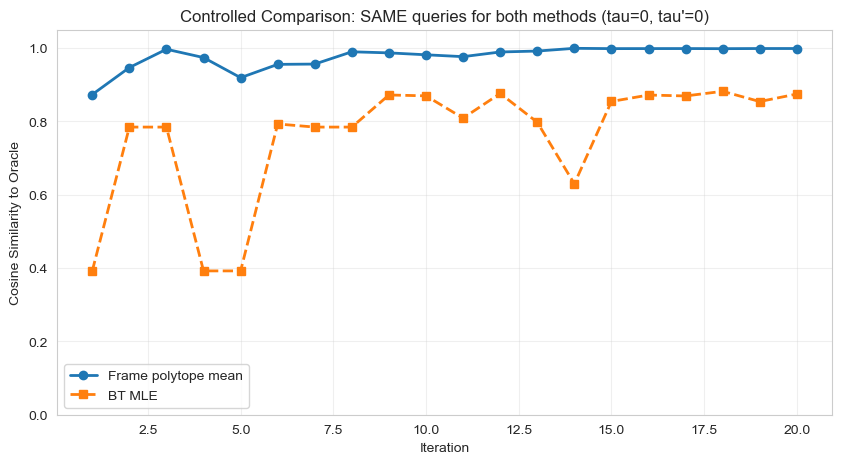


Final cosine similarities:
  Frame polytope: 0.9987
  BT MLE:         0.8746
  Difference:     0.1241

If these are similar, the tau=0,tau'=0 difference in sweep was due to random query selection.
The REAL advantage of polytope should appear when tau > 0, tau' > 0.


In [35]:
# The issue: BT and Polytope generate candidates independently with different RNG states
# Let's verify by running both with the SAME candidates and SAME query selection

np.random.seed(42)
test_w = np.array([0.1, 0.4, 0.1, 0.2, 0.2])
dim = 5
max_iter = 20

frame_oracle = make_frame_oracle(tau=0.0, tau_prime=0.0)

# Run both methods with SHARED query selection
poly_frame = ConstraintPolytope(dim, 'simplex')
poly_bt = ConstraintPolytope(dim, 'simplex')
comparisons_bt = []

frame_cos_history = []
bt_cos_history = []

for iteration in range(max_iter):
    # Sample from BOTH polytopes
    samples_frame = poly_frame.sample(500, burn_in=200, thin=3)
    samples_bt = poly_bt.sample(500, burn_in=200, thin=3)
    
    mean_frame = samples_frame.mean(axis=0)
    mean_bt = samples_bt.mean(axis=0)
    
    # Generate candidates ONCE and use for both
    np.random.seed(iteration * 1000)  # Reset seed for reproducibility
    candidates = generate_candidate_queries_normalized(50)
    
    # Select query using FRAME polytope samples (shared selection)
    query, _ = select_query_volume_removal(candidates, samples_frame, 0.0, 0.0, LAMBDA_X, decisive_only=False)
    delta_x = query.patient_left.to_array() - query.patient_right.to_array()
    
    # Get oracle response
    response = frame_oracle(query, test_w)
    
    # Add constraints to BOTH polytopes
    frame_constraints = response_to_constraints(query, response, tau=0.0, tau_prime=0.0, lambda_x=LAMBDA_X)
    for a, bv in frame_constraints:
        poly_frame.add_constraint(a, bv)
    
    if response == 'left':
        poly_bt.add_constraint(-delta_x, 0.0)
    else:
        poly_bt.add_constraint(delta_x, 0.0)
    
    y = 1 if response == 'left' else 0
    comparisons_bt.append((delta_x, y))
    
    # Compute cosine similarities
    frame_cos = np.dot(mean_frame, test_w) / (np.linalg.norm(mean_frame) * np.linalg.norm(test_w) + 1e-10)
    bt_mle = fit_bt_weights_mle(comparisons_bt)
    bt_cos = np.dot(bt_mle, test_w) / (np.linalg.norm(bt_mle) * np.linalg.norm(test_w) + 1e-10)
    
    frame_cos_history.append(frame_cos)
    bt_cos_history.append(bt_cos)

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, max_iter+1), frame_cos_history, 'o-', label='Frame polytope mean', linewidth=2)
ax.plot(range(1, max_iter+1), bt_cos_history, 's--', label='BT MLE', linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Cosine Similarity to Oracle')
ax.set_title('Controlled Comparison: SAME queries for both methods (tau=0, tau\'=0)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
plt.show()

print(f"\nFinal cosine similarities:")
print(f"  Frame polytope: {frame_cos_history[-1]:.4f}")
print(f"  BT MLE:         {bt_cos_history[-1]:.4f}")
print(f"  Difference:     {abs(frame_cos_history[-1] - bt_cos_history[-1]):.4f}")
print()
print("If these are similar, the tau=0,tau'=0 difference in sweep was due to random query selection.")
print("The REAL advantage of polytope should appear when tau > 0, tau' > 0.")

In [ ]:
# Isolate the difference: Is it constraints or estimation method?
# Compare: Frame polytope mean vs BT polytope mean vs BT MLE

print("Final comparison after shared queries:")
print("=" * 60)

# Sample from both final polytopes
final_samples_frame = poly_frame.sample(1000, burn_in=300, thin=5)
final_samples_bt = poly_bt.sample(1000, burn_in=300, thin=5)

frame_mean = final_samples_frame.mean(axis=0)
bt_poly_mean = final_samples_bt.mean(axis=0)
bt_mle = fit_bt_weights_mle(comparisons_bt)

frame_cos = np.dot(frame_mean, test_w) / (np.linalg.norm(frame_mean) * np.linalg.norm(test_w))
bt_poly_cos = np.dot(bt_poly_mean, test_w) / (np.linalg.norm(bt_poly_mean) * np.linalg.norm(test_w))
bt_mle_cos = np.dot(bt_mle, test_w) / (np.linalg.norm(bt_mle) * np.linalg.norm(test_w))

print(f"True weights:        {test_w}")
print()
print(f"Frame polytope mean: {frame_mean.round(4)}")
print(f"  cos_sim = {frame_cos:.4f}")
print()
print(f"BT polytope mean:    {bt_poly_mean.round(4)}")
print(f"  cos_sim = {bt_poly_cos:.4f}")
print()
print(f"BT MLE estimate:     {bt_mle.round(4)}")
print(f"  cos_sim = {bt_mle_cos:.4f}")
print()
print(f"Constraint counts: Frame={poly_frame.n_constraints}, BT={poly_bt.n_constraints}")
print()
print("Interpretation:")
print("  - If Frame mean ≈ BT poly mean: constraints are equivalent, MLE is the issue")
print("  - If Frame mean ≠ BT poly mean: constraints differ (check active frame masking)")

# Also check the actual constraint differences
print()
print("Checking constraint structure...")
print(f"Frame polytope has {poly_frame.n_constraints - 7} added constraints (excluding simplex)")
print(f"BT polytope has {poly_bt.n_constraints - 7} added constraints (excluding simplex)")

In [37]:
# DECISION: Use polytope mean for BOTH methods to isolate constraint effect
# This gives an apples-to-apples comparison of frame constraints vs BT constraints

def run_comparison_polytope_mean(
    oracle_weights: np.ndarray,
    tau: float,
    tau_prime: float,
    max_iterations: int = 30,
    n_samples: int = 500,
    n_candidates: int = 50,
) -> dict:
    """
    Compare BT vs Frame using POLYTOPE MEAN for both (not MLE for BT).
    This isolates the constraint structure advantage.
    """
    dim = len(FEATURE_NAMES)
    frame_oracle = make_frame_oracle(tau, tau_prime)
    
    results = {}
    
    # --- BT method (polytope mean, not MLE) ---
    polytope_bt = ConstraintPolytope(dim, 'simplex')
    bt_history = []
    
    for iteration in range(max_iterations):
        try:
            samples = polytope_bt.sample(n_samples, burn_in=200, thin=3)
        except ValueError:
            break
        
        mean_w = samples.mean(axis=0)
        
        candidates = generate_candidate_queries_normalized(n_candidates)
        query, _ = select_query_volume_removal(candidates, samples, tau, tau_prime, LAMBDA_X, decisive_only=False)
        
        true_response = frame_oracle(query, oracle_weights)
        
        # Forced choice for BT
        if true_response in ('left', 'right'):
            response = true_response
        else:
            response = np.random.choice(['left', 'right'])
        
        delta_x = query.patient_left.to_array() - query.patient_right.to_array()
        
        # BT constraint (tau=0 halfspace)
        if response == 'left':
            polytope_bt.add_constraint(-delta_x, 0.0)
        else:
            polytope_bt.add_constraint(delta_x, 0.0)
        
        cos_sim = np.dot(mean_w, oracle_weights) / (
            np.linalg.norm(mean_w) * np.linalg.norm(oracle_weights) + 1e-10)
        
        bt_history.append({
            'cosine_similarity': cos_sim,
            'true_response': true_response,
        })
    
    results['bt_polytope_mean'] = bt_history
    
    # --- Frame method (polytope mean) ---
    polytope_frame = ConstraintPolytope(dim, 'simplex')
    frame_history = []
    
    for iteration in range(max_iterations):
        try:
            samples = polytope_frame.sample(n_samples, burn_in=200, thin=3)
        except ValueError:
            break
        
        mean_w = samples.mean(axis=0)
        
        candidates = generate_candidate_queries_normalized(n_candidates)
        query, _ = select_query_volume_removal(candidates, samples, tau, tau_prime, LAMBDA_X, decisive_only=False)
        
        true_response = frame_oracle(query, oracle_weights)
        
        # Frame constraints (uses ALL responses including indiff/incomp)
        new_constraints = response_to_constraints(query, true_response, tau, tau_prime, LAMBDA_X)
        for a, bv in new_constraints:
            polytope_frame.add_constraint(a, bv)
        
        center = polytope_frame.chebyshev_center()
        if center is None:
            break
        
        cos_sim = np.dot(mean_w, oracle_weights) / (
            np.linalg.norm(mean_w) * np.linalg.norm(oracle_weights) + 1e-10)
        
        frame_history.append({
            'cosine_similarity': cos_sim,
            'true_response': true_response,
        })
    
    results['frame_polytope_mean'] = frame_history
    
    return results


print("Defined run_comparison_polytope_mean() - uses polytope mean for BOTH methods")

Defined run_comparison_polytope_mean() - uses polytope mean for BOTH methods


In [38]:
# Quick test: verify at tau=0, tau'=0 both methods are now equivalent
np.random.seed(42)
test_w = np.random.dirichlet(np.ones(5))

test_res = run_comparison_polytope_mean(test_w, tau=0.0, tau_prime=0.0, max_iterations=20)

bt_final = test_res['bt_polytope_mean'][-1]['cosine_similarity']
frame_final = test_res['frame_polytope_mean'][-1]['cosine_similarity']

print(f"Test at tau=0, tau'=0:")
print(f"  BT polytope mean:    {bt_final:.4f}")
print(f"  Frame polytope mean: {frame_final:.4f}")
print(f"  Difference:          {abs(bt_final - frame_final):.4f}")
print()
if abs(bt_final - frame_final) < 0.05:
    print("✓ Good! Methods are approximately equivalent at tau=0, tau'=0")
else:
    print("⚠ Still some difference - likely due to random query selection")

Test at tau=0, tau'=0:
  BT polytope mean:    0.9995
  Frame polytope mean: 0.9999
  Difference:          0.0004

✓ Good! Methods are approximately equivalent at tau=0, tau'=0


In [ ]:
# Re-run tau/tau' sweep with apples-to-apples comparison (polytope mean for both)
import time
from itertools import product

np.random.seed(123)

# Sweep parameters
tau_values_v2 = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
tau_prime_values_v2 = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

n_weights_v2 = 5
n_trials_v2 = 3
max_iter_v2 = 30

sweep_weights_v2 = np.random.dirichlet(np.ones(5), size=n_weights_v2)
sweep_results_v2 = {}

total_configs = len(tau_values_v2) * len(tau_prime_values_v2)
t0 = time.time()

for config_idx, (tau, tau_prime) in enumerate(product(tau_values_v2, tau_prime_values_v2)):
    bt_cos_finals = []
    frame_cos_finals = []
    
    for w_idx, w_vec in enumerate(sweep_weights_v2):
        for trial in range(n_trials_v2):
            np.random.seed(config_idx * 10000 + w_idx * 100 + trial)
            
            res = 
            
            
            lytope_mean(
                oracle_weights=w_vec,
                tau=tau,
                tau_prime=tau_prime,
                max_iterations=max_iter_v2,
            )
            
            if res['bt_polytope_mean']:
                bt_cos_finals.append(res['bt_polytope_mean'][-1]['cosine_similarity'])
            if res['frame_polytope_mean']:
                frame_cos_finals.append(res['frame_polytope_mean'][-1]['cosine_similarity'])
    
    sweep_results_v2[(tau, tau_prime)] = {
        'bt_cos': np.mean(bt_cos_finals) if bt_cos_finals else 0,
        'frame_cos': np.mean(frame_cos_finals) if frame_cos_finals else 0,
        'advantage': (np.mean(frame_cos_finals) - np.mean(bt_cos_finals)) if bt_cos_finals and frame_cos_finals else 0,
    }
    
    elapsed = time.time() - t0
    rate = (config_idx + 1) / elapsed if elapsed > 0 else 1
    remaining = (total_configs - config_idx - 1) / rate
    
    m = sweep_results_v2[(tau, tau_prime)]
    print(f'[{config_idx + 1}/{total_configs}] τ={tau:.1f}, τ\'={tau_prime:.1f} | '
          f'Frame: {m["frame_cos"]:.3f}, BT: {m["bt_cos"]:.3f}, '
          f'Advantage: {m["advantage"]:+.3f} | ~{remaining:.0f}s')

print(f'\nSweep v2 complete in {time.time() - t0:.1f}s')

In [ ]:
# Visualize v2 sweep results (apples-to-apples comparison)

n_tau_v2 = len(tau_values_v2)
n_tau_prime_v2 = len(tau_prime_values_v2)

advantage_matrix_v2 = np.zeros((n_tau_v2, n_tau_prime_v2))
frame_matrix_v2 = np.zeros((n_tau_v2, n_tau_prime_v2))
bt_matrix_v2 = np.zeros((n_tau_v2, n_tau_prime_v2))

for i, tau in enumerate(tau_values_v2):
    for j, tau_prime in enumerate(tau_prime_values_v2):
        m = sweep_results_v2[(tau, tau_prime)]
        advantage_matrix_v2[i, j] = m['advantage']
        frame_matrix_v2[i, j] = m['frame_cos']
        bt_matrix_v2[i, j] = m['bt_cos']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Heatmap 1: Advantage ---
ax = axes[0]
max_adv = max(0.1, np.abs(advantage_matrix_v2).max())
im = ax.imshow(advantage_matrix_v2, cmap='RdBu_r', vmin=-max_adv, vmax=max_adv, aspect='auto', origin='lower')
ax.set_xticks(range(n_tau_prime_v2))
ax.set_xticklabels([f'{t:.1f}' for t in tau_prime_values_v2])
ax.set_yticks(range(n_tau_v2))
ax.set_yticklabels([f'{t:.1f}' for t in tau_values_v2])
ax.set_xlabel("τ' (resolvability)")
ax.set_ylabel('τ (intensity)')
ax.set_title('Frame Advantage\n(Frame - BT, same estimation)', fontweight='bold')
plt.colorbar(im, ax=ax)

for i in range(n_tau_v2):
    for j in range(n_tau_prime_v2):
        val = advantage_matrix_v2[i, j]
        color = 'white' if abs(val) > max_adv * 0.5 else 'black'
        ax.text(j, i, f'{val:+.2f}', ha='center', va='center', fontsize=9, color=color)

# --- Heatmap 2: Frame cos_sim ---
ax = axes[1]
im = ax.imshow(frame_matrix_v2, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto', origin='lower')
ax.set_xticks(range(n_tau_prime_v2))
ax.set_xticklabels([f'{t:.1f}' for t in tau_prime_values_v2])
ax.set_yticks(range(n_tau_v2))
ax.set_yticklabels([f'{t:.1f}' for t in tau_values_v2])
ax.set_xlabel("τ' (resolvability)")
ax.set_ylabel('τ (intensity)')
ax.set_title('Frame Polytope Mean\nCosine Similarity', fontweight='bold')
plt.colorbar(im, ax=ax)

for i in range(n_tau_v2):
    for j in range(n_tau_prime_v2):
        val = frame_matrix_v2[i, j]
        color = 'white' if val < 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9, color=color)

# --- Heatmap 3: BT cos_sim ---
ax = axes[2]
im = ax.imshow(bt_matrix_v2, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto', origin='lower')
ax.set_xticks(range(n_tau_prime_v2))
ax.set_xticklabels([f'{t:.1f}' for t in tau_prime_values_v2])
ax.set_yticks(range(n_tau_v2))
ax.set_yticklabels([f'{t:.1f}' for t in tau_values_v2])
ax.set_xlabel("τ' (resolvability)")
ax.set_ylabel('τ (intensity)')
ax.set_title('BT Polytope Mean\nCosine Similarity', fontweight='bold')
plt.colorbar(im, ax=ax)

for i in range(n_tau_v2):
    for j in range(n_tau_prime_v2):
        val = bt_matrix_v2[i, j]
        color = 'white' if val < 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9, color=color)

fig.suptitle('Apples-to-Apples Comparison: Frame vs BT Constraints\n(Both use polytope mean estimation)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print key findings
print("\nKey findings:")
print("=" * 60)
print(f"At τ=0, τ'=0: Advantage = {advantage_matrix_v2[0, 0]:+.3f} (should be ~0)")
print(f"At τ=0.3, τ'=0.3: Advantage = {advantage_matrix_v2[3, 3]:+.3f}")
print(f"At τ=0.5, τ'=0.5: Advantage = {advantage_matrix_v2[5, 5]:+.3f}")
print()
print("The advantage should be ~0 at τ=0,τ'=0 and INCREASE as thresholds increase.")